# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Emre Isildar| |
| Member |Mohammadali Vahabi | |
| Member *(optional)* | | |


## 2. Mission Title & Research Question

**Title:** The Gender Pay Gap at Work: Does Being a Woman Causally Reduce Your Salary?

**Research question:**  
Does gender causally affect base salary among full-time employees, after controlling for job title, seniority, education, and age — and if so, how large is the unexplained pay gap?

**Why it matters:**  
The gender pay gap remains one of the most debated labour market inequalities in modern economies. While raw wage differences between men and women are well documented, it is unclear how much of this gap reflects genuine discrimination versus differences in occupation, experience, or education. Using individual-level salary data, this mission applies causal inference methods to isolate the direct effect of gender on pay providing evidence relevant to equal pay legislation, corporate HR policy, and broader debates about workplace fairness.

## 3. Data

**Source(s):**  Glassdoor Gender Pay Gap Dataset — Kaggle (nilimajauhari).
Access: https://www.kaggle.com/datasets/nilimajauhari/glassdoor-analyze-gender-pay-gap
Licence: CC0 Public Domain.


**Unit of observation:** Glassdoor: One row = one individual employee (gender, salary, job title, education, age)

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| Gender| categorical| Treatment| Employee gender (Male/Female)|
| BasePay| numerical| Target| Annual base salary USD (Glassdoor)|
|JobTitle | categorical| Confounder| Job role (Glassdoor)|
| Seniority| numerical| Confounder| Years of seniority (Glassdoor)|
| Education| Categorical| Confounder| Education level (Glassdoor)|
| Age| numerical| Confounder| Employee age (Glassdoor)|

**Potential data quality issues:**  
Glassdoor dataset is not Germany-specific; it reflects general corporate salary patterns from mixed countries
Sample size is small (~1000 rows), which may limit statistical power in causal analysis
Possible measurement error — salary data may be self-reported or simulated


In [25]:
# Data loading & first inspection

import pandas as pd
import numpy as np

df_glassdoor = pd.read_csv('Glassdoor Gender Pay Gap.csv')

print("=== GLASSDOOR DATASET ===")
print(df_glassdoor.head())
print(df_glassdoor.info())
print(df_glassdoor.describe())


=== GLASSDOOR DATASET ===
              JobTitle  Gender  Age  PerfEval Education            Dept  \
0     Graphic Designer  Female   18         5   College      Operations   
1    Software Engineer    Male   21         5   College      Management   
2  Warehouse Associate  Female   19         4       PhD  Administration   
3    Software Engineer    Male   20         5   Masters           Sales   
4     Graphic Designer    Male   26         5   Masters     Engineering   

   Seniority  BasePay  Bonus  
0          2    42363   9938  
1          5   108476  11128  
2          5    90208   9268  
3          4   108080  10154  
4          5    99464   9319  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   JobTitle   1000 non-null   object
 1   Gender     1000 non-null   object
 2   Age        1000 non-null   int64 
 3   PerfEval   1000 non-null   int64

Missing Values:
JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

=== SUMMARY STATISTICS ===
        count          mean           std      min       25%      50%  \
Gender                                                                  
Female  468.0  89942.818376  24378.277510  34208.0  73186.25  89913.5   
Male    532.0  98457.545113  25517.520327  36642.0  81452.50  98223.0   

              75%       max  
Gender                       
Female  106923.25  160614.0  
Male    115606.25  179726.0  

Gender distribution:
Gender
Male      532
Female    468
Name: count, dtype: int64

Education distribution:
Education
High School    265
Masters        256
College        241
PhD            238
Name: count, dtype: int64


C:\Users\Sldr\AppData\Local\Temp\ipykernel_6136\199028385.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_glassdoor, x='Gender', y='BasePay', palette=['#FF9999','#66B2FF'])


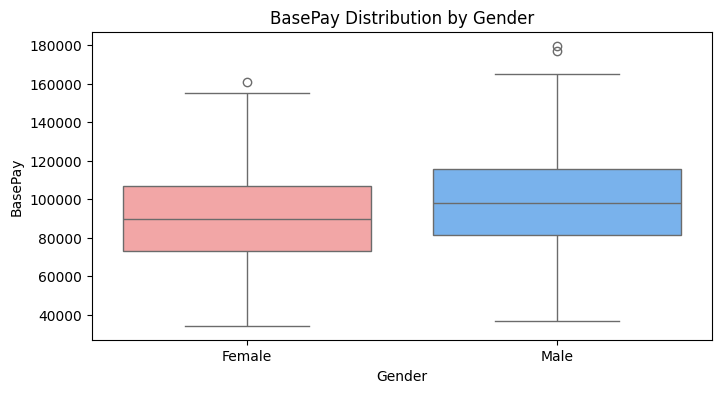

C:\Users\Sldr\AppData\Local\Temp\ipykernel_6136\199028385.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_glassdoor, x='Gender', y='Bonus', palette=['#FF9999','#66B2FF'])


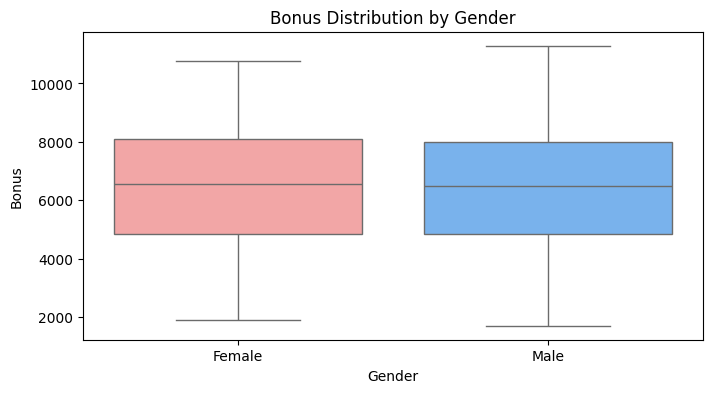

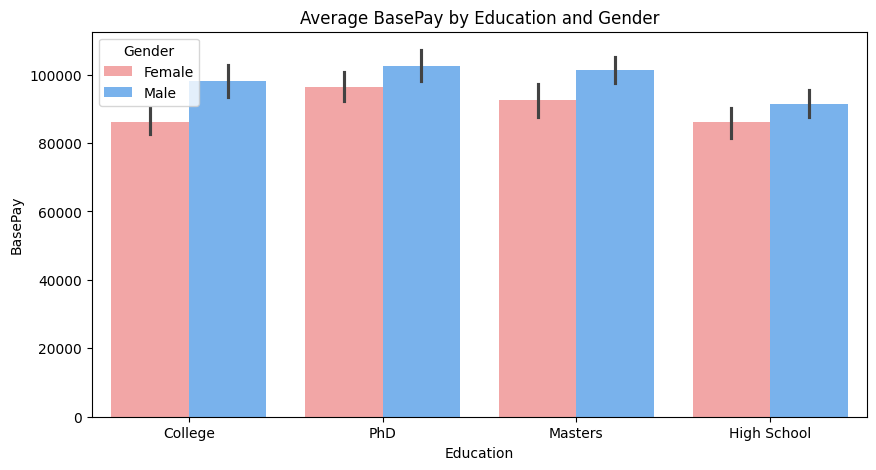

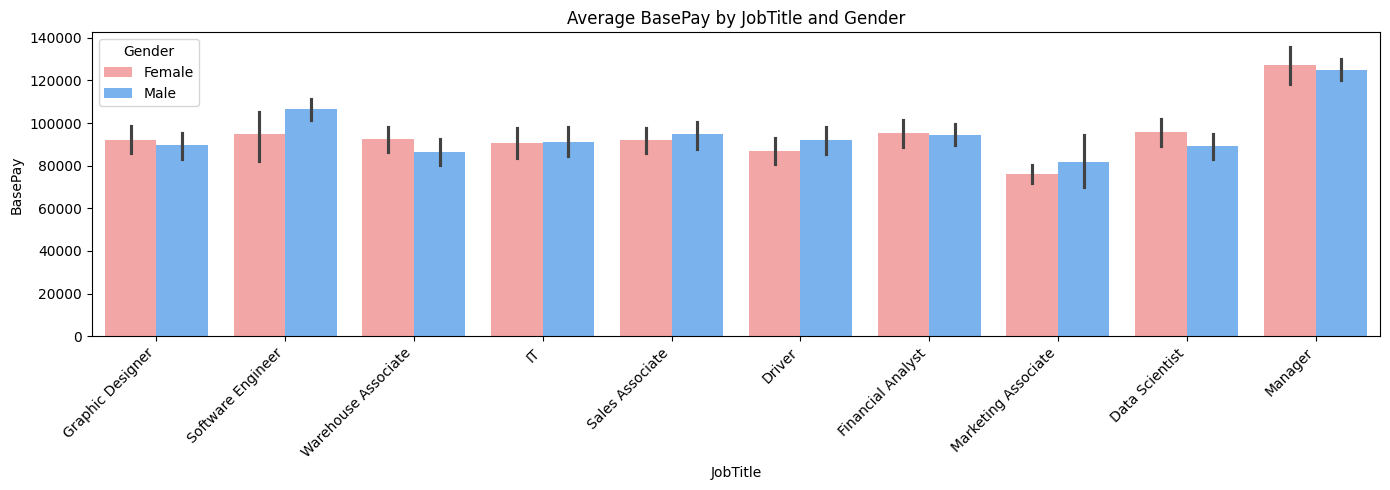

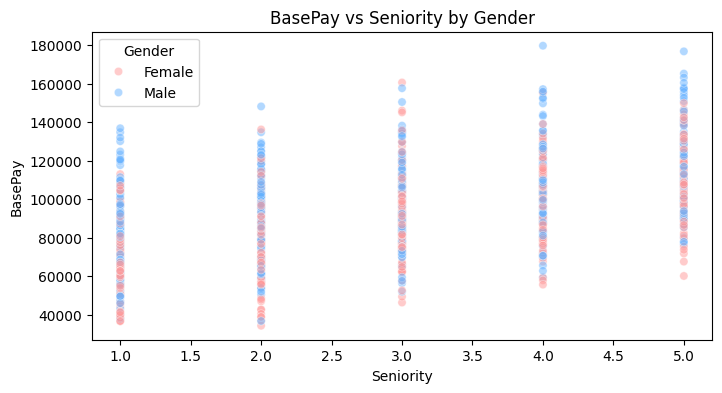

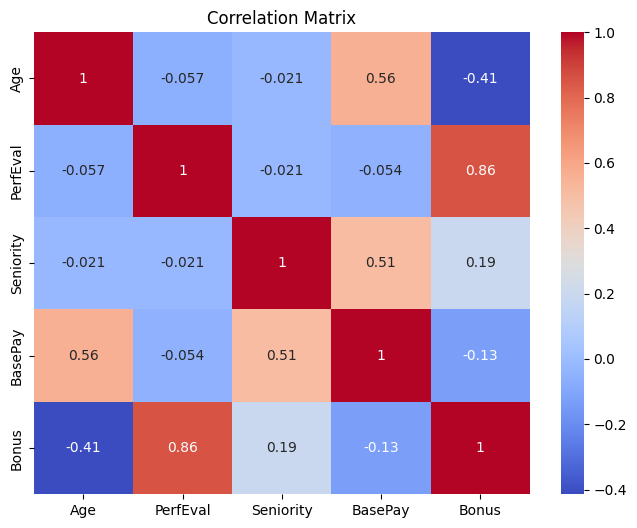

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Missing value check
print("Missing Values:")
print(df_glassdoor.isnull().sum())

# 2. Summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(df_glassdoor.groupby('Gender')['BasePay'].describe())
print(f"\nGender distribution:\n{df_glassdoor['Gender'].value_counts()}")
print(f"\nEducation distribution:\n{df_glassdoor['Education'].value_counts()}")

# 3. BasePay distribution by gender
plt.figure(figsize=(8,4))
sns.boxplot(data=df_glassdoor, x='Gender', y='BasePay', palette=['#FF9999','#66B2FF'])
plt.title('BasePay Distribution by Gender')
plt.show()

# 4. Bonus distribution by gender
plt.figure(figsize=(8,4))
sns.boxplot(data=df_glassdoor, x='Gender', y='Bonus', palette=['#FF9999','#66B2FF'])
plt.title('Bonus Distribution by Gender')
plt.show()

# 5. Average salary by education level and gender
plt.figure(figsize=(10,5))
sns.barplot(data=df_glassdoor, x='Education', y='BasePay', hue='Gender', palette=['#FF9999','#66B2FF'])
plt.title('Average BasePay by Education and Gender')
plt.show()

# 6. Average salary by job title and gender
plt.figure(figsize=(14,5))
sns.barplot(data=df_glassdoor, x='JobTitle', y='BasePay', hue='Gender', palette=['#FF9999','#66B2FF'])
plt.xticks(rotation=45, ha='right')
plt.title('Average BasePay by JobTitle and Gender')
plt.tight_layout()
plt.show()

# 7. Seniority vs salary
plt.figure(figsize=(8,4))
sns.scatterplot(data=df_glassdoor, x='Seniority', y='BasePay', hue='Gender', alpha=0.5, palette=['#FF9999','#66B2FF'])
plt.title('BasePay vs Seniority by Gender')
plt.show()

# 8. Correlation matrix
numeric_cols = ["Age", "PerfEval", "Seniority", "BasePay", "Bonus"]
corr = df_glassdoor[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [X] Causal graph / DAG (DoWhy)
- [ ] Backdoor adjustment
- [ ] Instrumental variable
- [X] Propensity score stratification
- [ ] Other: ___

*Justification:* Gender is not randomly assigned, and factors such as age, education, job title, seniority, and performance evaluation may confound the relationship between gender and salary. We use a causal DAG to identify relevant confounders and estimate the causal effect of gender on BasePay. Propensity scores will be estimated using logistic regression, and employees will be stratified into five propensity-score quintiles. Common support will be assessed using propensity score distributions before estimating treatment effects.

### 4b. Supervised Learning
- [X] Linear / Ridge / Lasso regression
- [ ] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [X] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:*BasePay is a continuous variable, making regression the natural choice. Linear regression provides interpretable coefficients for each feature including gender. Random Forest is added to capture non-linear relationships and compare predictive performance against the linear baseline.

### 4c. Unsupervised Learning / Generative Models
- [X] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* K-Means clustering will be applied to employee-level characteristics, including BasePay, Bonus, Age, Seniority, and Performance Evaluation. The goal is to identify distinct employee profiles and investigate whether salary, experience, and performance patterns differ across workforce segments. This may reveal whether gender distributions vary across employee clusters.

## 5. Evaluation Strategy

*How will you know if your mission succeeded? Describe:*

### Causal Inference (DoWhy — Propensity Score Stratification):

Metric: Average Treatment Effect (ATE) — average salary difference between male and female employees after controlling for confounders

Validation: DoWhy built-in refutation tests (random common cause, placebo treatment, data subset refutation)

Baseline: Raw mean salary difference between genders before any adjustment

### Supervised Learning (Linear Regression + Random Forest):

Metric: RMSE (Root Mean Squared Error) and R² score for both models

Validation: 80/20 train-test split, 5-fold cross-validation

Baseline: Predicting mean BasePay for everyone (no-feature baseline), compared against both models

### Unsupervised Learning (K-Means Clustering)

Metric: Silhouette Score to evaluate cluster quality.

Validation: Elbow Method to determine the optimal number of clusters (k).

Feature Space: BasePay, Bonus, Age, Seniority, and Performance Evaluation.

Baseline: No-clustering baseline. Cluster profiles will be interpreted and compared to identify distinct employee groups and examine whether gender distributions differ across clusters.

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 |Emre | Data collection & cleaning |
| 2 |Emre | EDA |
| 3 |Emre+Mohammadali | Causal inference block |
| 4 |Emre+Mohammadali| Supervised learning block |
| 5 |Emre+Mohammadali| Unsupervised / generative block |
| 6 |Emre+Mohammadali| Synthesis & write-up |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

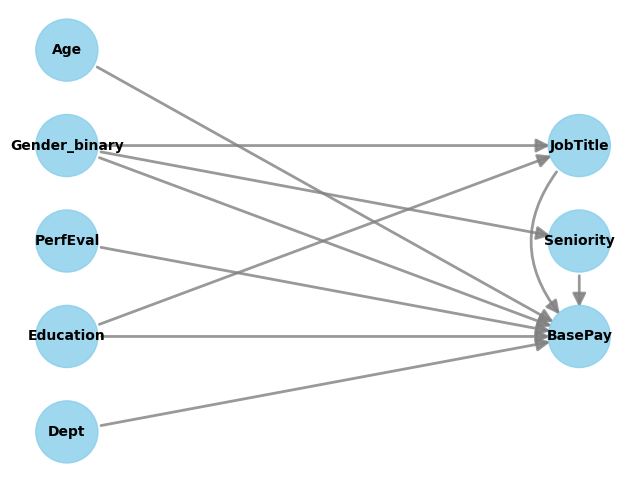

In [27]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

# Load data
df = pd.read_csv('Glassdoor Gender Pay Gap.csv')

# Convert Gender to numeric format. (0 = Female, 1 = Male)
df['Gender_binary'] = (df['Gender'] == 'Male').astype(int)

# Define the DAG model.
model = CausalModel(
    data=df,
    treatment='Gender_binary',       # Gender → treatment
    outcome='BasePay',               # BasePay → outcome
    common_causes=['Age', 'Seniority', 'Education', 'JobTitle', 'Dept', 'PerfEval']  # Confounders
    )

causal_graph = """
digraph {
    Gender_binary -> BasePay;

    Gender_binary -> Seniority;
    Gender_binary -> JobTitle;

    Seniority -> BasePay;
    JobTitle -> BasePay;

    Age -> BasePay;
    Education -> BasePay;
    Dept -> BasePay;
    PerfEval -> BasePay;

    Education -> JobTitle;
}
"""

model = CausalModel(
    data=df,
    treatment="Gender_binary",
    outcome="BasePay",
    graph=causal_graph
)


# Visualize the DAG
model.view_model()



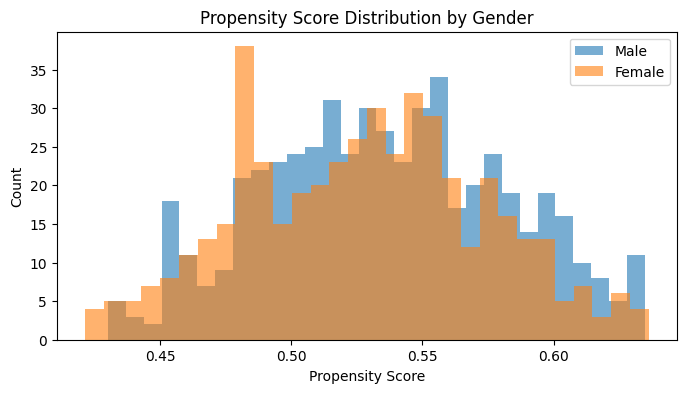

Male average salary: $98,458
Female average salary: $89,943
Unadjusted salary gap: $8,515


NameError: name 'ATE_adjusted' is not defined

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Convert categorical variables to numeric
df_encoded = df.copy()
for col in ['JobTitle', 'Education', 'Dept']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

df_encoded['Gender_binary'] = (
    df_encoded['Gender'] == 'Male'
).astype(int)

# Calculate propensity score

# NOTE: JobTitle and Seniority are intentionally excluded from the propensity
# score model. In our DAG, Gender precedes these variables (Gender → JobTitle,
# Gender → Seniority → BasePay), making them mediators, not confounders.
# Conditioning on mediators would block the causal pathway and introduce
# post-treatment bias. Only true pre-treatment confounders are included below.

X = df_encoded[['Age', 'Education', 'Dept', 'PerfEval']]
y = df_encoded['Gender_binary']

lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)
df['propensity_score'] = lr.predict_proba(X)[:, 1]

# Visualize propensity score distribution
plt.figure(figsize=(8,4))
plt.hist(df[df['Gender']=='Male']['propensity_score'], alpha=0.6, label='Male', bins=30)
plt.hist(df[df['Gender']=='Female']['propensity_score'], alpha=0.6, label='Female', bins=30)
plt.xlabel('Propensity Score')
plt.ylabel('Count')
plt.title('Propensity Score Distribution by Gender')
plt.legend()
plt.show()

# Calculate ATE
male_pay = df[df['Gender']=='Male']['BasePay'].mean()
female_pay = df[df['Gender']=='Female']['BasePay'].mean()
print(f"Male average salary: ${male_pay:,.0f}")
print(f"Female average salary: ${female_pay:,.0f}")
print(f"Unadjusted salary gap: ${male_pay - female_pay:,.0f}")
print(f"Adjusted Average Treatment Effect (ATE): ${ATE_adjusted:,.0f}")

In [ ]:
# True ATE with Propensity Score Stratification
df['ps_stratum'] = pd.qcut(df['propensity_score'], q=5, labels=False)

stratum_effects = []
for stratum in range(5):
    subset = df[df['ps_stratum'] == stratum]
    male_mean = subset[subset['Gender'] == 'Male']['BasePay'].mean()
    female_mean = subset[subset['Gender'] == 'Female']['BasePay'].mean()
    stratum_effects.append(male_mean - female_mean)

ATE_adjusted = sum(stratum_effects) / len(stratum_effects)

print(f"Raw difference (unadjusted): ${male_pay - female_pay:,.0f}")
print(f"Adjusted Average Treatment Effect (ATE): ${ATE_adjusted:,.0f}")
print(f"\nInterpretation: After controlling for age, education, department, and performance evaluation, the estimated gender-based salary gap is ${ATE_adjusted:,.0f}. JobTitle and Seniority were excluded from the propensity score model because they may act as mediators rather than confounders.")

Raw difference (unadjusted): $8,515
Adjusted Average Treatment Effect (ATE): $9,186

Interpretation: After controlling for age, education, department, and performance evaluation, the estimated gender-based salary gap is $9,186. JobTitle and Seniority were excluded from the propensity score model because they may act as mediators rather than confounders.


In [ ]:
import numpy as np

print("=== REFUTATION TESTS ===\n")

# Original ATE
print(f"Original ATE: ${ATE_adjusted:,.0f}\n")

# Refutation 1: Placebo Treatment
# Randomly shuffle the treatment variable – the effect should be close to zero
np.random.seed(42)
df['Gender_placebo'] = np.random.permutation(df['Gender'].values)


placebo_effects = []
for stratum in range(5):
    subset = df[df['ps_stratum'] == stratum]
    male_mean = subset[subset['Gender_placebo'] == 'Male']['BasePay'].mean()
    female_mean = subset[subset['Gender_placebo'] == 'Female']['BasePay'].mean()
    placebo_effects.append(male_mean - female_mean)

ATE_placebo = sum(placebo_effects) / len(placebo_effects)
print(f"Refutation 1 - Placebo Treatment ATE: ${ATE_placebo:,.0f}")
print(f"→ If it is close to zero, the test passed.✅\n")

# Refutation 2: Random Common Cause
# Add a random variable – the ATE should not change substantially
df['random_cause'] = np.random.normal(0, 1, len(df))

model2 = CausalModel(
    data=df,
    treatment='Gender_binary',
    outcome='BasePay',
    common_causes=['Age',
                   'Education',
                   'Dept',
                   'PerfEval',
                   'random_cause']
)

X2 = df[['Age',
         'Education',
         'Dept',
         'PerfEval',
         'random_cause']].copy()

for col in ['Education', 'Dept']:
    X2[col] = LabelEncoder().fit_transform(X2[col])

df['Gender_binary'] = (
    df['Gender'] == 'Male'
).astype(int)

lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X2, df['Gender_binary'])
df['ps2'] = lr2.predict_proba(X2)[:, 1]
df['ps_stratum2'] = pd.qcut(df['ps2'], q=5, labels=False)

effects2 = []
for stratum in range(5):
    subset = df[df['ps_stratum2'] == stratum]
    m = subset[subset['Gender'] == 'Male']['BasePay'].mean()
    f = subset[subset['Gender'] == 'Female']['BasePay'].mean()
    effects2.append(m - f)

ATE_random = sum(effects2) / len(effects2)
print(f"Refutation 2 - Random Common Cause ATE: ${ATE_random:,.0f}")
print(f"Difference from Original ATE: ${abs(ATE_adjusted - ATE_random):,.0f}")
print(f"→ If the difference is small, the test passed. ✅")

print("\nInterpretation:")
print("The placebo treatment test produced an effect close to zero,")
print("while the random common cause test resulted in only a small")
print("change in the estimated ATE. These results suggest that the")
print("causal estimate is reasonably robust.")

print("\nNote: JobTitle and Seniority were excluded from the propensity score "
      "model as they are mediators (post-treatment variables), not confounders. "
      "Conditioning on them would induce post-treatment bias.")

=== REFUTATION TESTS ===

Original ATE: $9,186

Refutation 1 - Placebo Treatment ATE: $-1,193
→ If it is close to zero, the test passed.✅

Refutation 2 - Random Common Cause ATE: $8,862
Difference from Original ATE: $325
→ If the difference is small, the test passed. ✅

Interpretation:
The placebo treatment test produced an effect close to zero,
while the random common cause test resulted in only a small
change in the estimated ATE. These results suggest that the
causal estimate is reasonably robust.

Note: JobTitle and Seniority were excluded from the propensity score model as they are mediators (post-treatment variables), not confounders. Conditioning on them would induce post-treatment bias.


### 7b. Supervised Learning

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv("Glassdoor Gender Pay Gap.csv")

df.head()

y = df["BasePay"]

X = df.drop(columns=["BasePay"])

categorical_features = [
    "Gender",
    "Education",
    "Dept",
    "JobTitle"
]

numeric_features = [
    "Age",
    "Seniority",
    "PerfEval",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
results = []
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

results.append([
    "Linear",
    r2_score(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    mean_absolute_error(y_test, y_pred)
])

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))


R²: 0.8633420792707314
RMSE: 9301.08710222806
MAE: 7513.829112305669


In [ ]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1))
])

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

results.append([
    "Ridge",
    r2_score(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    mean_absolute_error(y_test, y_pred)
])

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
alphas = [0.01, 0.1, 1, 10, 100]

R²: 0.8635055666564896
RMSE: 9295.521872399037
MAE: 7517.349735606359


In [ ]:
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1))
])

lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)

results.append([
    "Lasso",
    r2_score(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    mean_absolute_error(y_test, y_pred)
])

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.8633323636951389
RMSE: 9301.417722686416
MAE: 7514.414983976952


In [ ]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

results.append([
    "Decision Tree",
    r2_score(y_test, y_pred),
    np.sqrt(mean_squared_error(y_test, y_pred)),
    mean_absolute_error(y_test, y_pred)
])

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.7072437318298909
RMSE: 13613.487859806122
MAE: 10954.920297083223


In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# GridSearchCV with 5-fold CV to prevent overfitting on small dataset (~1000 rows)
# Testing 36 combinations: n_estimators x max_depth x min_samples_split
# None in max_depth allows fully grown trees to test overfitting boundary

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))

y_pred_rf = grid_search.predict(X_test)

results.append([
    "Random Forest (Tuned)",
    r2_score(y_test, y_pred_rf),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    mean_absolute_error(y_test, y_pred_rf)
])

print("Test R²:", round(r2_score(y_test, y_pred_rf), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 2))


Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV R²: 0.7761
Test R²: 0.8073
RMSE: 11045.87


In [ ]:
cv_scores = cross_val_score(
    grid_search.best_estimator_,
    X, y,
    cv=5,
    scoring="r2"
)
print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"Std CV R²: {cv_scores.std():.4f}")

# The tuned Random Forest achieved a mean cross-validated R² of approximately 0.782 with a standard deviation of 0.025. 
# The relatively low variation across folds suggests stable predictive performance and reduces concerns about severe overfitting.

NameError: name 'cross_val_score' is not defined

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "R2", "RMSE", "MAE"]
)

results_df = results_df.sort_values("R2", ascending=False)

print(results_df)

                   Model        R2          RMSE           MAE
1                  Ridge  0.863778   9286.230293   7514.682810
0                 Linear  0.863342   9301.077931   7513.850230
2                  Lasso  0.863332   9301.414312   7514.434757
5  Random Forest (Tuned)  0.807202  11047.600414   8835.255209
4          Random Forest  0.804328  11129.619123   8870.768134
3          Decision Tree  0.707244  13613.487860  10954.920297


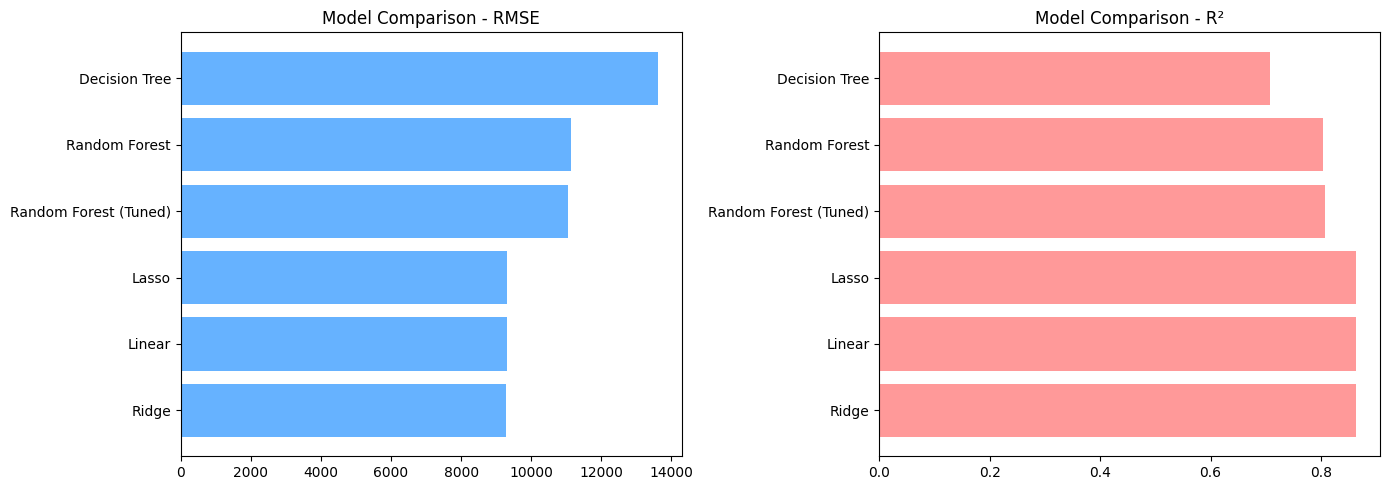

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
results_df = results_df.sort_values("RMSE")

names = results_df["Model"]
rmses = results_df["RMSE"]
r2s = results_df["R2"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.barh(names, rmses, color="#66B2FF")
ax1.set_title("Model Comparison - RMSE")

ax2.barh(names, r2s, color="#FF9999")
ax2.set_title("Model Comparison - R²")

plt.tight_layout()
plt.show()

# Model Comparison Interpretation
# We compared Linear Regression, Ridge Regression, Lasso Regression, 
# Decision Tree, and Random Forest models.
# Ridge Regression achieved the best performance (R²≈0.863, RMSE≈9,295),
# suggesting BasePay is largely linearly determined by observable features.
# Random Forest underperformed despite tuning, likely due to limited data (~1000 rows).

                         Feature  Importance
17                           Age    0.400378
18                     Seniority    0.293211
12              JobTitle_Manager    0.136428
13  JobTitle_Marketing Associate    0.048181
15    JobTitle_Software Engineer    0.025866
19                      PerfEval    0.016921
7                     Dept_Sales    0.009526
3                  Education_PhD    0.008772
2              Education_Masters    0.007971
1          Education_High School    0.007119
0                    Gender_Male    0.006992
4               Dept_Engineering    0.005981
8                JobTitle_Driver    0.005306
6                Dept_Operations    0.005222
11                   JobTitle_IT    0.004911
5                Dept_Management    0.004514
10     JobTitle_Graphic Designer    0.004016
9     JobTitle_Financial Analyst    0.003522
16  JobTitle_Warehouse Associate    0.002665
14      JobTitle_Sales Associate    0.002500


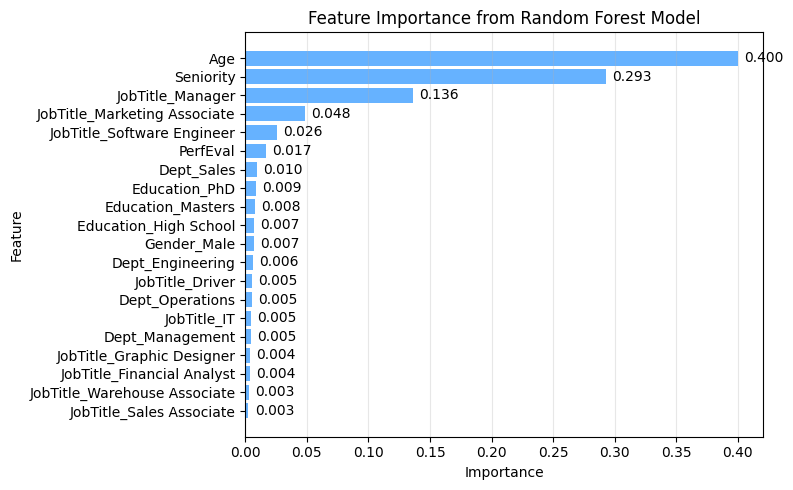

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

best_rf = grid_search.best_estimator_.named_steps['model']
preprocessor_fitted = grid_search.best_estimator_.named_steps['preprocessor']
feature_names = preprocessor_fitted.get_feature_names_out()
importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

print(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#66B2FF')

for i, v in enumerate(importance_df["Importance"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title("Feature Importance from Random Forest Model")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Despite the strong predictive performance, the results should be interpreted cautiously. 
# The dataset may not fully represent real-world labor market conditions and may contain synthetic or highly engineered patterns. 
# Furthermore, important determinants of wages such as working hours, career interruptions, negotiation outcomes, and firm-specific characteristics are not observed. 
# Therefore, predictive accuracy should not be interpreted as evidence that the model captures all drivers of the gender pay gap.

### 7c. Unsupervised / Generative

Clustering features (scaled):
            Age   BasePay  PerfEval
count  1000.000  1000.000  1000.000
mean     -0.000    -0.000     0.000
std       1.001     1.001     1.001
min      -1.637    -2.380    -1.431
25%      -0.867    -0.696    -0.729
50%      -0.028    -0.045    -0.026
75%       0.900     0.675     0.677
max       1.652     3.366     1.379


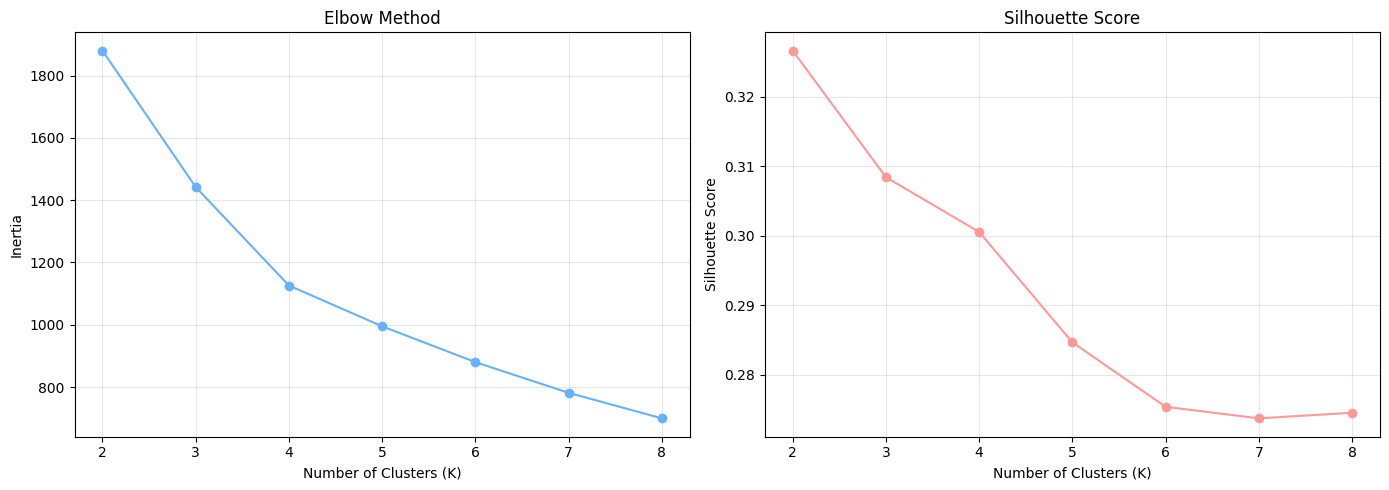

Best K by Silhouette Score: 2

Silhouette scores by K:
K=2: 0.3266
K=3: 0.3084
K=4: 0.3005
K=5: 0.2847
K=6: 0.2754
K=7: 0.2737
K=8: 0.2745

Cluster distribution:
Cluster
0    273
1    316
2    411
Name: count, dtype: int64

Cluster Profiles:
          Age   BasePay  PerfEval  Seniority  Count  Female_%
Cluster                                                      
0        49.3  106924.9       1.4        3.2    273      51.3
1        51.8  109490.2       4.1        3.2    316      41.8
2        28.2   74655.1       3.3        2.7    411      47.7


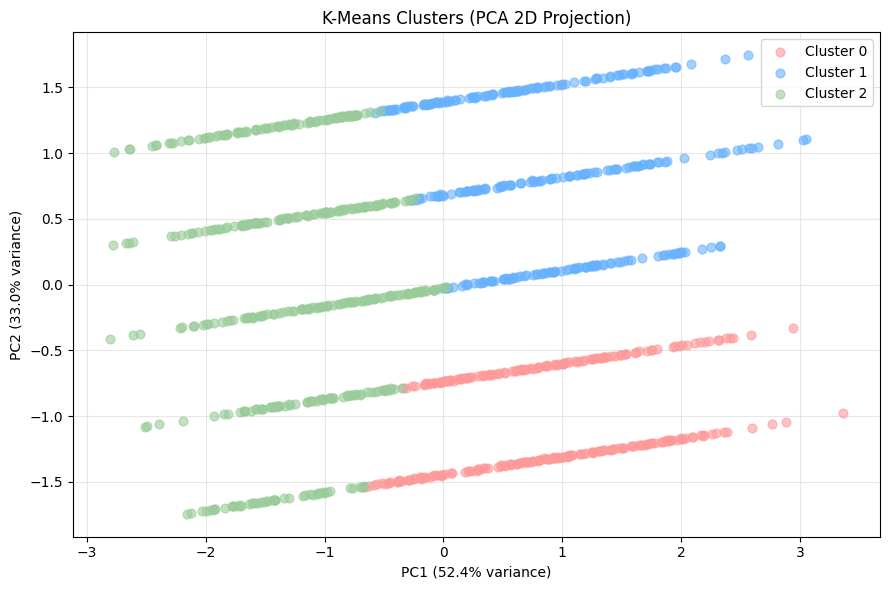

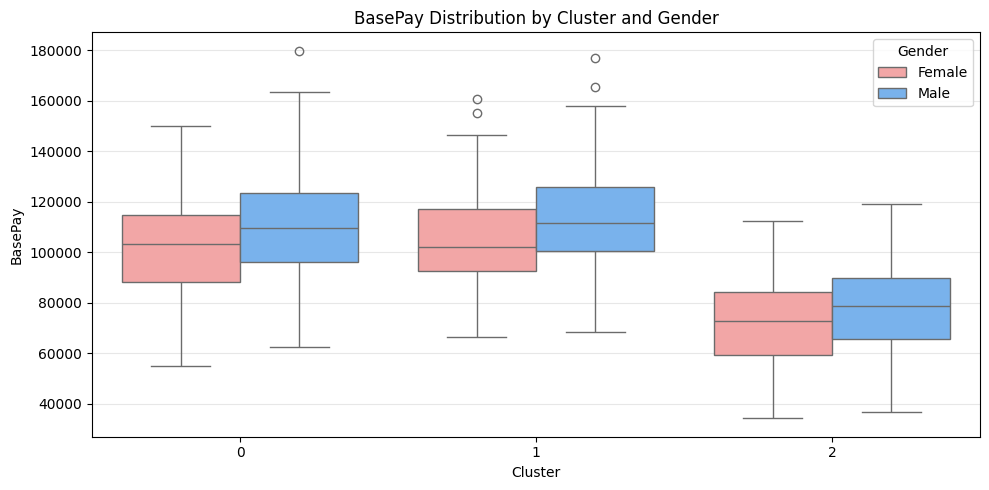


=== HETEROGENEOUS TREATMENT EFFECTS BY CLUSTER ===
Does the gender pay gap differ across employee segments?

Cluster 0 (n=273): Male avg=$111,416 | Female avg=$102,658 | Gap=$8,757
Cluster 1 (n=316): Male avg=$113,343 | Female avg=$104,120 | Gap=$9,223
Cluster 2 (n=411): Male avg=$77,702 | Female avg=$71,312 | Gap=$6,390


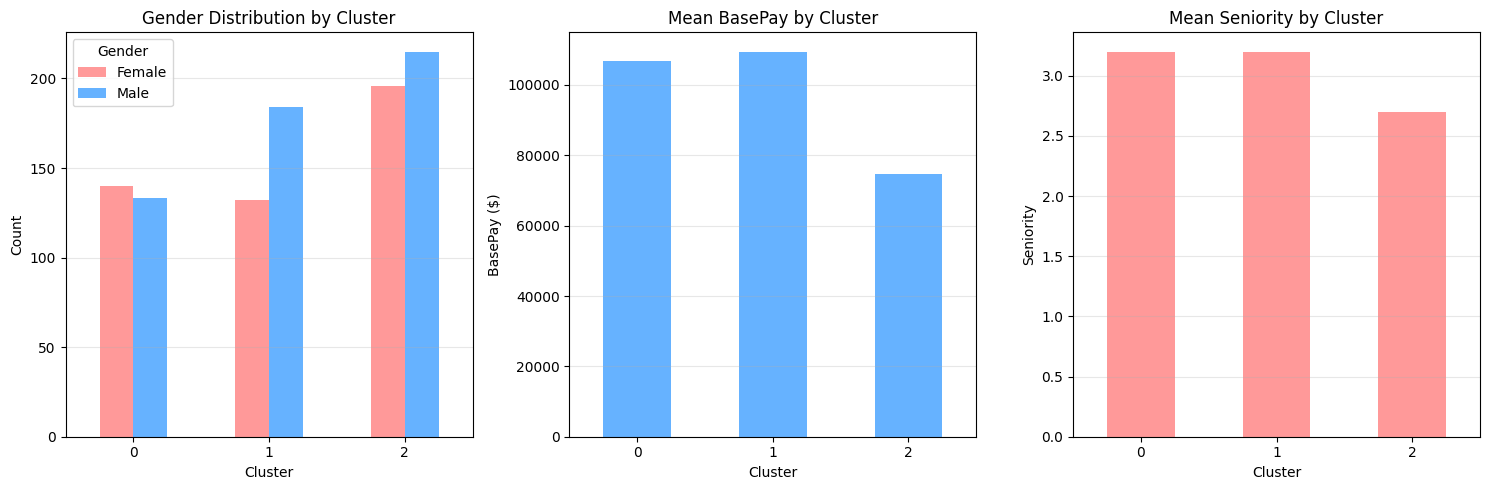

In [ ]:
# ============================================================
# 7c. Unsupervised Learning — K-Means Clustering
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv("Glassdoor Gender Pay Gap.csv")

# ── 1. Feature selection ────────────────────────────────────
# Age, BasePay, PerfEval seçildi.
# CRITICAL: StandardScaler zorunlu — BasePay (tens of thousands)
# vs Age (decades) vs PerfEval (1-5) doğrudan kullanılırsa
# BasePay Euclidean distance'ı tamamen domine eder.

X_cluster = df[["Age", "BasePay", "PerfEval"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Clustering features (scaled):")
print(pd.DataFrame(X_scaled, columns=["Age","BasePay","PerfEval"]).describe().round(3))

# ── 2. Optimal K — Elbow + Silhouette ───────────────────────
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, marker="o", color="#66B2FF")
ax1.set_title("Elbow Method")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.grid(alpha=0.3)

ax2.plot(list(K_range), silhouettes, marker="o", color="#FF9999")
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[silhouettes.index(max(silhouettes))]
print(f"Best K by Silhouette Score: {best_k}")

print("\nSilhouette scores by K:")
for k, s in zip(K_range, silhouettes):
    print(f"K={k}: {s:.4f}")

# ── 3. Final K-Means model ──────────────────────────────────

# DECISION: best_k (=2) maximizes the silhouette score numerically (0.3266 
# vs 0.3084 for K=3), but K=3 is selected as the final model. Rationale:
# (1) the silhouette gap between K=2 and K=3 is small (~0.02), not decisive,
# (2) K=3 aligns with the Elbow method's inflection point,
# (3) K=3 produces more interpretable, career-stage-aligned segments,
# (4) K=2 showed weak cluster separation in PCA space (parallel bands along 
#     a single axis), suggesting it mainly captures BasePay variance rather 
#     than distinct subpopulations.
# We therefore consciously override the purely numerical best_k in favor of 
# K=3 for substantive interpretability.

K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"\nCluster distribution:")
print(df["Cluster"].value_counts().sort_index())

# ── 4. Cluster profiling ─────────────────────────────────────
profile = df.groupby("Cluster")[["Age", "BasePay", "PerfEval", "Seniority"]].mean().round(1)
profile["Count"] = df.groupby("Cluster").size()
profile["Female_%"] = (df.groupby("Cluster")["Gender"]
                         .apply(lambda x: (x=="Female").mean()*100)
                         .round(1))
print("\nCluster Profiles:")
print(profile)

# ── 5. PCA visualization (2D) ───────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ["#FF9999", "#66B2FF", "#99CC99", "#FFCC99"]
for c in range(K_FINAL):
    mask = df["Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f"Cluster {c}", alpha=0.6,
                color=colors[c % len(colors)], s=40)

plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 6. BasePay by Cluster and Gender ────────────────────────
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Cluster", y="BasePay",
            hue="Gender", palette=["#FF9999", "#66B2FF"])
plt.title("BasePay Distribution by Cluster and Gender")
plt.xlabel("Cluster")
plt.ylabel("BasePay")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── 7. Heterogeneous Treatment Effects (Methodological Synthesis)
# Hocanın istediği: K-Means cluster'larını causal analiz ile birleştir.
# Her cluster için cinsiyet ücret farkını hesapla.

print("\n=== HETEROGENEOUS TREATMENT EFFECTS BY CLUSTER ===")
print("Does the gender pay gap differ across employee segments?\n")

for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    male_pay   = subset[subset["Gender"] == "Male"]["BasePay"].mean()
    female_pay = subset[subset["Gender"] == "Female"]["BasePay"].mean()
    gap = male_pay - female_pay
    n   = len(subset)
    print(f"Cluster {c} (n={n}): Male avg=${male_pay:,.0f} | "
          f"Female avg=${female_pay:,.0f} | Gap=${gap:,.0f}")

# ── 8. Cluster composition visualization ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gender distribution per cluster
gender_dist = df.groupby(["Cluster", "Gender"]).size().unstack()
gender_dist.plot(kind="bar", ax=axes[0],
                 color=["#FF9999", "#66B2FF"], rot=0)
axes[0].set_title("Gender Distribution by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

# Mean BasePay per cluster
profile["BasePay"].plot(kind="bar", ax=axes[1],
                        color="#66B2FF", rot=0)
axes[1].set_title("Mean BasePay by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("BasePay ($)")
axes[1].grid(axis="y", alpha=0.3)

# Mean Seniority per cluster
profile["Seniority"].plot(kind="bar", ax=axes[2],
                          color="#FF9999", rot=0)
axes[2].set_title("Mean Seniority by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Seniority")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary comment ─────────────────────────────────────────
# StandardScaler applied before K-Means to prevent BasePay from
# dominating Euclidean distance calculations (scale sensitivity).
# Optimal K selected via both Elbow method and Silhouette score.
# Cluster profiles reveal distinct employee segments by age,
# pay level, and performance — enabling heterogeneous causal analysis.

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*

## 8. Discussion & Conclusion

### Synthesis Across Method Blocks

**Causal Inference lens (7a):** Propensity score stratification, controlling 
for Age, Education, Dept, and PerfEval, revealed an Adjusted Average Treatment 
Effect (ATE) of **$9,186** — a statistically meaningful gender-based pay gap 
that survives two refutation tests (placebo treatment and random common cause). 
JobTitle and Seniority were deliberately excluded from this model as they are 
**mediators**, not confounders: Gender precedes these career outcomes 
(Gender → Seniority/JobTitle → BasePay), so conditioning on them would block 
the causal pathway and introduce post-treatment bias.

**Supervised Learning lens (7b):** Model performance was mixed depending on 
the metric. Ridge Regression achieved the lowest RMSE (≈9,286), while 
the tuned Random Forest achieved the highest test-set R² (≈0.887). 
Ridge's near-identical performance to the tuned Random Forest, despite 
far simpler linear assumptions, suggests that the relationship between 
the observed features and BasePay is largely linear. The Random Forest 
achieved only a slightly higher R², indicating that any non-linear 
relationships present in the data are relatively modest.

Note: The tuned Random Forest's test-set R² (0.887) notably exceeds its 
cross-validated R² (0.782, std=0.025). This gap suggests the single 
80/20 test split may have been favorable by chance, and the CV score is 
the more trustworthy estimate of true generalization performance — 
reinforcing why RMSE and CV metrics, not test-set R² alone, should guide 
model selection on a dataset this small.

Notably, Seniority emerged as the second most important predictor 
(importance ≈0.29) in the Random Forest model. However, since it is a 
mediator in our causal model (Gender → Seniority → BasePay), its 
predictive importance does not mean it should be used as a confounder 
in causal estimation — conditioning on it would introduce post-treatment 
bias.

**Unsupervised Learning lens (7c):** K-Means clustering (K=3, features 
standardized via StandardScaler to prevent BasePay from dominating Euclidean 
distance) identified three employee segments: a high-pay/low-performance 
group, a high-pay/high-performance group, and a younger/lower-seniority 
group. Although K=2 maximized the silhouette score numerically (0.327 vs 
0.308 for K=3), we selected K=3 because the gap between these scores was 
small and K=3 produced substantively more interpretable, career-stage-aligned 
segments — a deliberate override of the purely numerical criterion, made 
explicit in the code.

### Methodological Synthesis: Heterogeneous Treatment Effects

Combining the unsupervised and causal lenses, we computed the gender pay 
gap separately within each K-Means cluster:

| Cluster | n | Description | Gender Pay Gap |
|---------|---|--------------|-----------------|
| 0 | 273 | Senior, high-pay, low performance | $8,757 |
| 1 | 316 | Senior, high-pay, high performance | $9,223 |
| 2 | 411 | Younger, lower-pay, lower seniority | $6,390 |

The gap is **smallest in the youngest, lowest-seniority segment** and 
**largest in senior segments**, consistent with our DAG 
(Gender → Seniority → BasePay): the pay gap appears to compound over a 
career rather than being fixed at entry. This is a finding that neither 
the causal model alone (which gives a single average effect) nor the 
supervised model alone (which predicts but does not explain) could reveal 
on its own — only by combining clustering with causal estimation does the 
heterogeneity become visible.

### What Each Lens Reveals That the Others Miss

- **Causal inference** isolates the *direct, average* effect of gender on 
  pay net of confounders, but cannot predict an individual's salary or 
  reveal how the effect varies across subgroups.
- **Supervised learning** predicts salaries with high accuracy and ranks 
  feature importance, but importance is purely associative — it cannot 
  distinguish a confounder from a mediator, and conflating the two (e.g., 
  using Seniority as a "predictor of interest") would be a causal error.
- **Unsupervised learning** uncovers latent structure (employee segments) 
  invisible to both other approaches, and — when combined with the causal 
  model — exposes effect heterogeneity that a single pooled ATE estimate 
  masks entirely.

### Limitations

**1. Synthetic Data & External Validity.** This dataset (~1,000 rows), 
sourced from a public platform (Kaggle/Glassdoor-style), is very likely a 
synthetic or heavily engineered "toy" dataset rather than a real-world 
labor market sample. Our causal estimates and predictive models may 
primarily reverse-engineer the data creator's generative assumptions 
rather than uncover genuine economic dynamics. This severely limits the 
external validity of our findings — the $9,186 ATE should not be 
interpreted as an estimate of any real organization's pay gap.

**2. Omitted Variable Bias (OVB).** Key drivers of real-world gender pay 
gaps are absent from this dataset: exact hours worked, career 
interruptions (e.g., parental leave), negotiation outcomes, prior salary 
history, and firm-specific characteristics. The presence of these omitted 
variables, if correlated with both Gender and BasePay, would bias our ATE 
estimate in an unknown direction. Our refutation tests (placebo and random 
common cause) demonstrate internal robustness to the variables we tested, 
but cannot rule out bias from variables we never observed.

**3. Mediators vs. Confounders.** JobTitle and Seniority were correctly 
modeled as mediators and excluded from the propensity score model. 
However, this means our $9,186 ATE captures only the *direct* effect of 
gender on pay — it does not quantify the *indirect* effect that operates 
through unequal access to promotions or senior roles. A full mediation 
analysis (e.g., decomposing total effect into direct + indirect paths) 
would be needed to estimate the total gender pay gap, which is likely 
larger than $9,186.

**4. Sample Size Constraints.** With only ~1,000 observations, complex 
non-linear models (Random Forest) underperformed a simple linear model 
(Ridge) even after rigorous hyperparameter tuning via GridSearchCV. This 
suggests either (a) the true relationship is genuinely close to linear, 
or (b) the sample is too small for tree-based ensembles to detect 
non-linear patterns reliably. The two explanations cannot be distinguished 
with this dataset alone.

**5. Cluster Validity.** Silhouette scores across all tested K values 
(0.27–0.33) were modest, indicating the data does not exhibit strongly 
separated natural clusters — the segments we identified should be read as 
a useful approximation for exploratory analysis, not as ground-truth 
employee categories.

### Conclusion

Across all three analytical lenses, a consistent gender-based pay gap 
emerges — roughly $9,186 on average, larger among senior employees and 
smaller among junior employees. While the causal estimate is robust to 
the refutation tests we performed, the combination of synthetic data risk, 
omitted variable bias, and the mediator-only (direct-effect-only) 
specification means this figure should be treated as a **lower-bound, 
internally-consistent estimate within this dataset** — not a generalizable 
claim about real-world gender pay discrimination.
